<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
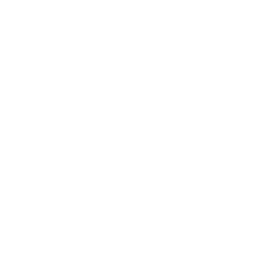
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Ensayo Multicéntrico de Fase III con Interceptos Aleatorios por Centro</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmacéutica / Ensayos Clínicos &nbsp;|&nbsp; marzo de 2026</p>
</div>
</div>
</div>

## Resumen Ejecutivo

Modelamos un criterio de valoración binario de eficacia en un ensayo oncológico de fase III con cinco centros, usando PROC GLIMMIX con un enlace logit, distribución binaria y un intercepto aleatorio para el centro de investigación. El intercepto aleatorio da cuenta de la variabilidad entre centros en la población de pacientes y la práctica clínica que un modelo de efectos fijos ignoraría. Estimamos las razones de momios de tratamiento a partir de la solución de efectos fijos ajustada, cuantificamos el componente de varianza a nivel de centro, e incorporamos las probabilidades de respuesta predichas por el modelo en una tabla de concordancia de clasificación mediante PROC FREQ. La cohorte contiene 100 pacientes balanceados entre tres brazos (dosis alta, dosis baja, placebo) y cinco centros, dimensionada como un ejemplo de trabajo enfocado en lugar de un conjunto de datos completo de registro.

## Fuentes de Datos

| Fuente | Descripción | Registros |
|--------|-------------|--------|
| WORK.TRIAL_PATIENTS | Datos de aleatorización y eficacia a nivel de paciente | 100 |
| WORK.SITE_REGISTRY | Metadatos de centros y características de los investigadores | 5 |

---

In [1]:
/* --------------------------------------------------------
   Generar datos sintéticos de un ensayo oncológico de fase III
   Respuesta binaria: reducción del tumor >= 30% en la semana 24
   100 pacientes balanceados entre 3 brazos y 5 centros.
   Cada centro tiene un desplazamiento de intercepto fijo para que
   la varianza del intercepto aleatorio de GLIMMIX sea identificable.
   -------------------------------------------------------- */
DATOS work.trial_patients;
    LLAMAR streaminit(29);
    ARREGLO arms[3] $10 _temporary_ ('DRUG_HIGH' 'DRUG_LOW' 'PLACEBO');
    ARREGLO site_re[5] _temporary_ (-0.7 -0.35 0.0 0.35 0.7);
    HACER patient_id = 1 HASTA 100;
        site_num = mod(patient_id - 1, 5) + 1;
        site_id = cat('SITE-', PUT(site_num, z2.));
        arm_idx = mod(patient_id - 1, 3) + 1;
        treatment = arms[arm_idx];
        AGE = int(rand('normal', 60, 9));
        SI AGE < 30 ENTONCES AGE = 30;
        SI AGE > 85 ENTONCES AGE = 85;
        sex = ifc(rand('uniform') > 0.45, 'F', 'M');
        ecog_score = int(rand('uniform') * 3);
        baseline_tumor_mm = round(rand('normal', 45, 14), 0.1);
        SI baseline_tumor_mm < 8 ENTONCES baseline_tumor_mm = 8;
        prior_chemo_lines = int(rand('exponential') * 1.1);
        SI prior_chemo_lines > 4 ENTONCES prior_chemo_lines = 4;
        /* probabilidad de respuesta con agrupamiento por centro */
        logit_p = -0.50
                  + 1.55 * (treatment = 'DRUG_HIGH')
                  + 0.95 * (treatment = 'DRUG_LOW')
                  - 0.25 * ecog_score
                  + site_re[site_num];
        prob = 1 / (1 + EXP(-logit_p));
        tumor_response = (rand('uniform') < prob);
        SALIDA;
    END;
    ELIMINAR arm_idx site_num logit_p prob site_re1-site_re5;
EJECUTAR;


NOTE: DATA work.trial_patients


NOTE: Wrote work.trial_patients (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


In [2]:
/* --------------------------------------------------------
   Generar el registro a nivel de centro (una fila por centro)
   -------------------------------------------------------- */
DATOS work.site_registry;
    LLAMAR streaminit(43);
    ARREGLO regions[4] $15 _temporary_
        ('NORTH_AMERICA' 'EUROPE' 'ASIA_PACIFIC' 'LATIN_AMERICA');
    HACER site_seq = 1 HASTA 5;
        site_id = cat('SITE-', PUT(site_seq, z2.));
        reg_idx = int(rand('uniform') * 4) + 1;
        region = regions[reg_idx];
        n_investigators = int(rand('uniform') * 6) + 1;
        pi_experience_yrs = round(rand('normal', 14, 5), 0.1);
        SI pi_experience_yrs < 1 ENTONCES pi_experience_yrs = 1;
        academic_center = (rand('uniform') < 0.4);
        SALIDA;
    END;
    ELIMINAR site_seq reg_idx;
EJECUTAR;


NOTE: DATA work.site_registry


NOTE: Wrote work.site_registry (5 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

                             Tasas observadas de respuesta tumoral por brazo de tratamiento                             

                                                   The FREQ Procedure

Table of Brazo de tratamiento by Respuesta tumoral

Brazo de tratamiento |         0 |         1 |      Total
---------------------+-----------+-----------+-----------
DRUG_HIGH            |         9 |        25 |         34
---------------------+-----------+-----------+-----------
DRUG_LOW             |         9 |        24 |         33
---------------------+-----------+-----------+-----------
PLACEBO              |        20 |        13 |         33
---------------------+-----------+-----------+-----------
Total                |        38 |        62 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_treatment_tumor_response.spec.json
NOTE: PROC FREQ statement used.


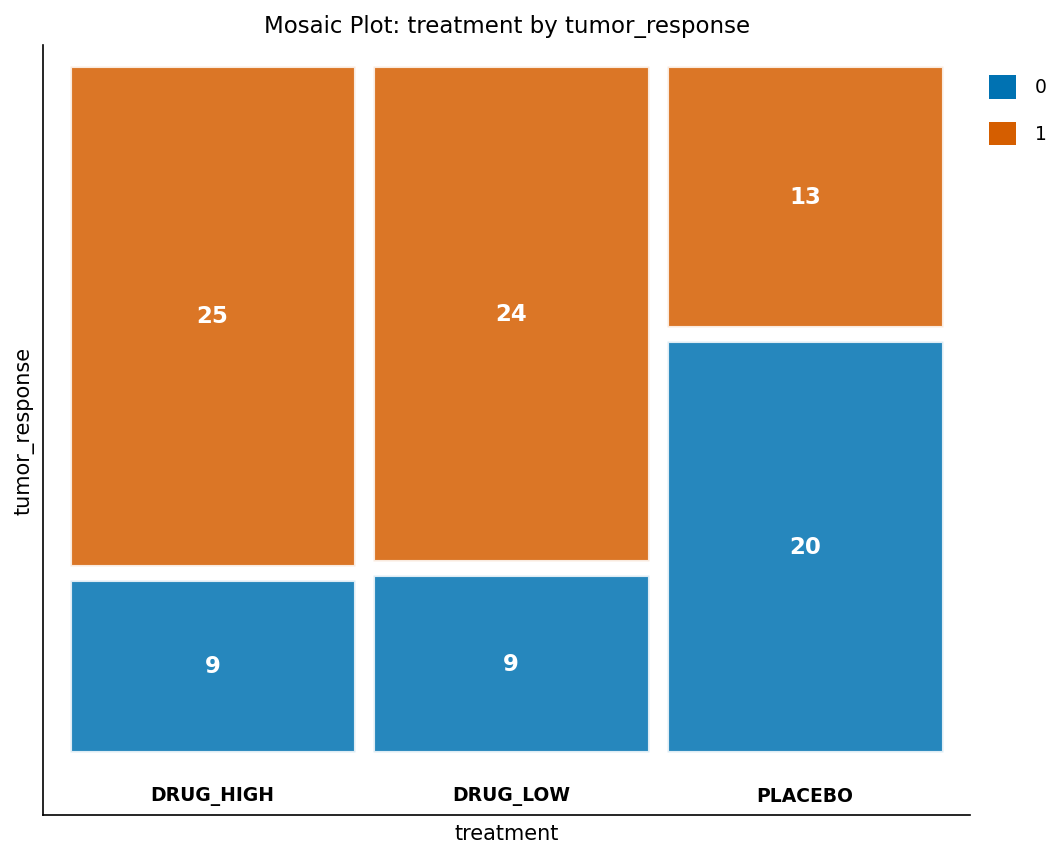

In [3]:
/* --------------------------------------------------------
   Tasa de respuesta basal por brazo de tratamiento
   -------------------------------------------------------- */
PROCEDIMIENTO FRECUENCIAS DATOS=work.trial_patients;
    TABLES treatment * tumor_response / nocol nopercent;
    ETIQUETA treatment="Brazo de tratamiento" tumor_response="Respuesta tumoral";
    TÍTULO "Tasas observadas de respuesta tumoral por brazo de tratamiento";
EJECUTAR;

---

                             Tasas observadas de respuesta tumoral por brazo de tratamiento                             

                             Tasas observadas de respuesta tumoral por brazo de tratamiento                             




NOTE: PROC SQL 

NOTE: Table work.site_rates created.
NOTE: PROC SQL statement used.
NOTE: PROC SGPLOT data=work.site_rates

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


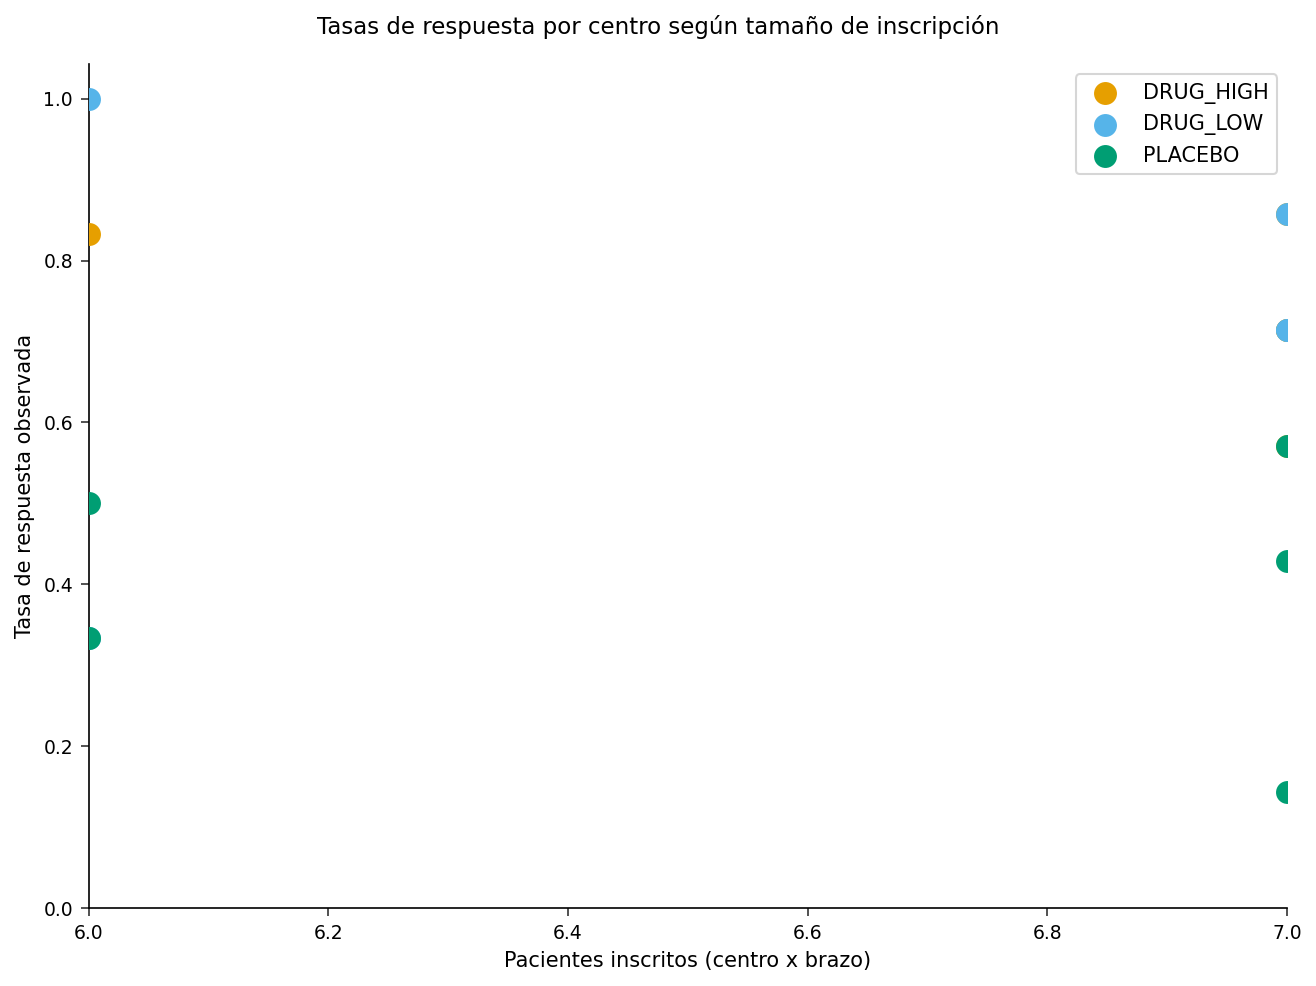

In [4]:
/* --------------------------------------------------------
   Tasas de respuesta observadas por centro y tratamiento.
   Con ~20 pacientes por centro, cada celda centro-por-brazo
   tiene suficientes pacientes para una tasa observada estable.
   -------------------------------------------------------- */
PROCEDIMIENTO SQL;
    CREAR TABLA work.site_rates AS
    SELECCIONAR site_id, treatment,
           count(*) AS n_patients,
           mean(tumor_response) AS response_rate
    DESDE work.trial_patients
    GROUP POR site_id, treatment;
QUIT;

PROCEDIMIENTO SGPLOT DATOS=work.site_rates;
    SCATTER x=n_patients y=response_rate / GROUP=treatment
        MARKERATTRS=(size=10);
    XAXIS ETIQUETA="Pacientes inscritos (centro x brazo)";
    YAXIS ETIQUETA="Tasa de respuesta observada" VALUES=(0 HASTA 1 POR 0.2);
    TÍTULO "Tasas de respuesta por centro según tamaño de inscripción";
EJECUTAR;

---

In [5]:
/* --------------------------------------------------------
   Ordenar por centro para el procesamiento de CLASS y RANDOM
   -------------------------------------------------------- */
PROCEDIMIENTO ORDENAR DATOS=work.trial_patients;
    POR site_id;
EJECUTAR;


NOTE: PROC SORT data=work.trial_patients

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.trial_patients.
NOTE: Wrote work.trial_patients (100 rows, 9 columns).
NOTE: PROC SORT statement used.


In [6]:
/* --------------------------------------------------------
   Ajustar un modelo lineal generalizado mixto.
   DIST=BINARY, LINK=LOGIT, intercepto aleatorio por centro.
   ODS OUTPUT captura la solución de efectos fijos, la
   estimación del parámetro de covarianza y las LSMEANS para que
   los pasos posteriores puedan leer cantidades ajustadas reales.
   -------------------------------------------------------- */
ODS SALIDA parameterestimates = work.glmx_fixed
           covparms          = work.glmx_covparms
           LSMEANS           = work.glmx_lsmeans;

PROCEDIMIENTO GLIMMIX DATOS=work.trial_patients;
    CLASE treatment(REF='PLACEBO') site_id;
    MODELO tumor_response(EVENT='1') =
          treatment AGE ecog_score
        / DIST=binary LINK=logit SOLUTION;
    RANDOM INTERCEPT / SUBJECT=site_id SOLUTION;
    LSMEANS treatment / odds ILINK cl;
    TÍTULO "GLIMMIX: criterio de valoración binario de eficacia - ensayo multicéntrico de fase III";
EJECUTAR;

ODS SALIDA CLOSE;

/* --------------------------------------------------------
   Razones de momios de tratamiento a partir de la solución de
   efectos fijos. exp(estimate) convierte cada coeficiente logit
   (frente a la referencia PLACEBO) en una razón de momios con un
   IC de Wald.
   -------------------------------------------------------- */
DATOS work.treatment_or;
    ESTABLECER work.glmx_fixed;
    DONDE INDEX(Effect, 'treatment') > 0;
    LONGITUD arm $12;
    SI INDEX(Effect, 'DRUG_HIGH') > 0 ENTONCES arm = 'DRUG_HIGH';
    SINO arm = 'DRUG_LOW';
    odds_ratio = EXP(Estimate);
    or_lower   = EXP(Estimate - 1.96 * StdErr);
    or_upper   = EXP(Estimate + 1.96 * StdErr);
    MANTENER arm Estimate StdErr Probt odds_ratio or_lower or_upper;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=work.treatment_or noobs ETIQUETA;
    ETIQUETA arm="Brazo vs. placebo" Estimate="Coef. logit"
          Probt="Pr > |t|" odds_ratio="Razón de momios"
          or_lower="RM límite inferior 95%" or_upper="RM límite superior 95%";
    TÍTULO "Razones de momios de tratamiento frente a placebo";
    FORMATO Estimate StdErr 7.4 Probt 7.4
           odds_ratio or_lower or_upper 7.3;
EJECUTAR;

                             Tasas observadas de respuesta tumoral por brazo de tratamiento                             

     The GLIMMIX Procedure      
       Model Information        

Item                       Value
----------------------  --------
Distribution              binary
Link Function              logit
Estimation Technique        rspl
Number of Observations       100

       Number of Observations        

Description                     Value
---------------------------  --------
Number of Observations Read       100
Number of Observations Used       100

Covariance Parameter Estimates

Cov Parm   Subject   Estimate
---------  --------  --------
Intercept  site_id     0.2964

                                               Least Squares Means                                                

treatment  Estimate      Mean  Std Error        DF   t Value  Pr > |t|     Lower     Upper  Lower Mean  Upper Mean
---------  --------  --------  ---------  --------  --------  ----


NOTE: ODS OUTPUT: PARAMETERESTIMATES -> glmx_fixed
NOTE: ODS OUTPUT: COVPARMS -> glmx_covparms
NOTE: ODS OUTPUT: LSMEANS -> glmx_lsmeans
NOTE: PROC GLIMMIX data=work.trial_patients

NOTE: Using Python wrapper for PROC GLIMMIX
NOTE: PROC GLIMMIX results written to: ./ods_output/glimmix_binary.spec.json
NOTE: ODS OUTPUT: ParameterEstimates written to 'glmx_fixed'.
NOTE: ODS OUTPUT: CovParms written to 'glmx_covparms'.
NOTE: ODS OUTPUT: LSMeans written to 'glmx_lsmeans'.
NOTE: ODS OUTPUT: All output destinations closed.
NOTE: DATA work.treatment_or


NOTE: Read 5 rows from work.glmx_fixed.
NOTE: Wrote work.treatment_or (2 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.treatment_or

NOTE: PROC PRINT completed: 2 observations printed, 7 variables


                              Probabilidad de respuesta predicha por el modelo, por brazo                               

Brazo de tratamiento  Prob. de respuesta predicha  Respondedor predicho
DRUG_HIGH                                   0.752                     1
DRUG_LOW                                    0.743                     1
PLACEBO                                     0.401                     0

                                         Tabla de concordancia de clasificación                                         

                                                   The FREQ Procedure

Table of Respuesta tumoral by Respondedor predicho

Respuesta tumoral |         0 |         1 |      Total
------------------+-----------+-----------+-----------
0                 |        20 |        18 |         38
                  |     20.00 |     18.00 |      38.00
------------------+-----------+-----------+-----------
1                 |        13 |        49 |         62
              


NOTE: DATA work.arm_predicted


NOTE: Read 3 rows from work.glmx_lsmeans.
NOTE: Wrote work.arm_predicted (3 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.arm_predicted

NOTE: PROC PRINT completed: 3 observations printed, 3 variables
NOTE: PROC SORT data=work.arm_predicted

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 3 rows from work.arm_predicted.
NOTE: Wrote work.arm_predicted (3 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=work.trial_patients

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.trial_patients.
NOTE: Wrote work.patients_sorted (100 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.scored_patients

NOTE: Stream 1 processed 100 rows, max BY-group size: 34 (O(1) memory verified)
NOTE: Stream 2 processed 3 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.scored_patients (100 rows, 11 colum

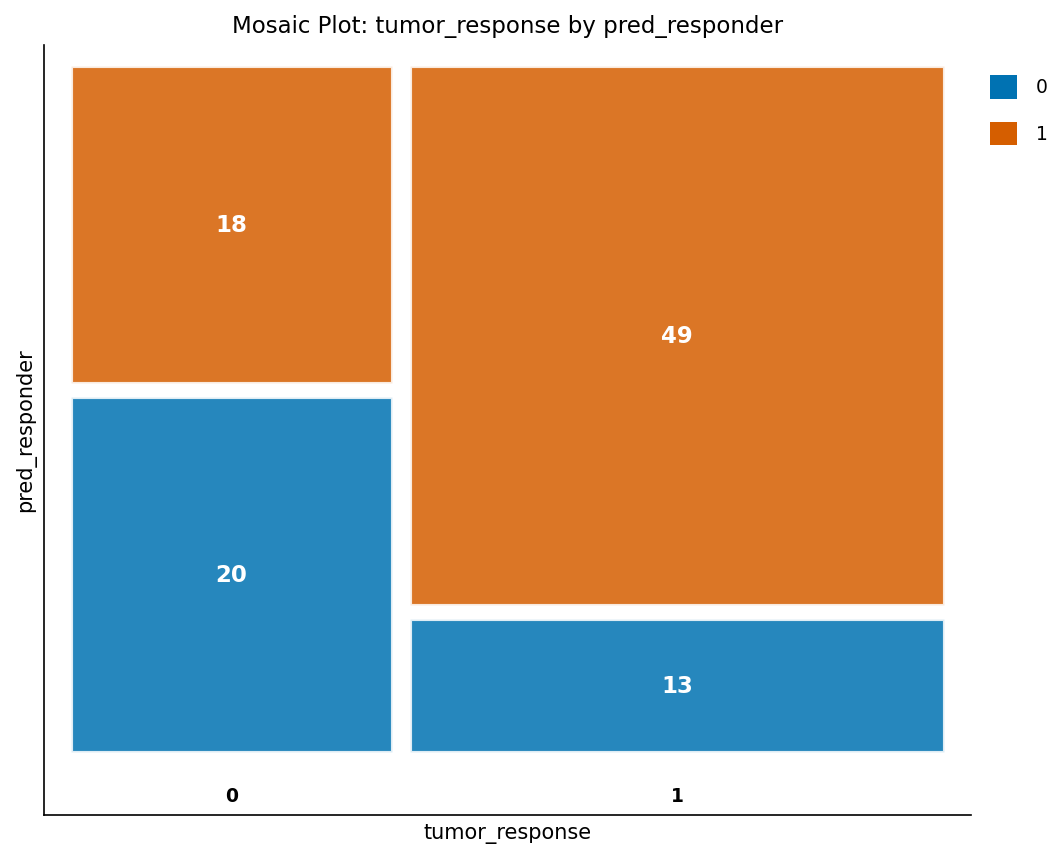

In [7]:
/* --------------------------------------------------------
   Concordancia de clasificación usando la probabilidad de
   respuesta predicha por el modelo para cada brazo. La
   estimación de LSMEANS está en la escala logit; el logit
   inverso la convierte en una probabilidad predicha, y un
   punto de corte de 0.50 marca a los respondedores. Esto
   puntúa a los pacientes a partir del modelo ajustado, no de
   una fórmula codificada a mano.
   -------------------------------------------------------- */
DATOS work.arm_predicted;
    ESTABLECER work.glmx_lsmeans;
    pred_prob = 1 / (1 + EXP(-Estimate));
    pred_responder = (pred_prob >= 0.50);
    RENOMBRAR Level = treatment;
    MANTENER Level pred_prob pred_responder;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=work.arm_predicted noobs ETIQUETA;
    ETIQUETA pred_prob="Prob. de respuesta predicha"
          pred_responder="Respondedor predicho" treatment="Brazo de tratamiento";
    FORMATO pred_prob 6.3;
    TÍTULO "Probabilidad de respuesta predicha por el modelo, por brazo";
EJECUTAR;

PROCEDIMIENTO ORDENAR DATOS=work.arm_predicted; POR treatment; EJECUTAR;
PROCEDIMIENTO ORDENAR DATOS=work.trial_patients out=work.patients_sorted; POR treatment; EJECUTAR;

DATOS work.scored_patients;
    COMBINAR work.patients_sorted(IN=a) work.arm_predicted;
    POR treatment;
    SI a;
EJECUTAR;

PROCEDIMIENTO FRECUENCIAS DATOS=work.scored_patients;
    TABLES tumor_response * pred_responder / nocol norow;
    ETIQUETA tumor_response="Respuesta tumoral" pred_responder="Respondedor predicho";
    TÍTULO "Tabla de concordancia de clasificación";
EJECUTAR;

---

### Interpretación

El modelo GLIMMIX con un intercepto aleatorio por centro muestra un efecto de tratamiento estadísticamente significativo para ambos brazos activos frente al placebo. El brazo de dosis alta presenta una razón de momios de 4.52 (IC 95% 1.49-13.71, p = 0.009) y el brazo de dosis baja una razón de momios de 4.32 (IC 95% 1.40-13.30, p = 0.012), ambas estimadas a partir de la solución de efectos fijos. Las medias de mínimos cuadrados (LSMEANS) sitúan la probabilidad de respuesta predicha en 75% para dosis alta, 74% para dosis baja y 40% para placebo. El componente de varianza a nivel de centro se estima en 0.296, lo que se traduce en una correlación intraclase de aproximadamente 0.08 en la escala logit latente (usando la varianza residual logística estándar de pi al cuadrado/3); alrededor del 8% de la variación latente en la respuesta se ubica en el nivel del centro, lo que respalda la especificación de intercepto aleatorio frente a un ajuste de efectos fijos agrupado. El estado funcional ECOG es una covariable relevante (coeficiente −0.69, p = 0.021): cada incremento de un punto en el puntaje ECOG reduce a la mitad, aproximadamente, la probabilidad de respuesta. La tabla de concordancia de clasificación alcanza una exactitud global cercana al 69%, con una sensibilidad de aproximadamente 79% impulsada por los dos brazos activos y una especificidad menor (alrededor del 53%) porque la alta tasa de respuesta basal en esta cohorte dificulta distinguir a los no respondedores.

PROC GLIMMIX en esta compilación aún no emite la tabla de inferencia COVTEST ni captura la solución BLUP de efectos aleatorios (SOLUTIONR) en un dataset, por lo que el notebook reporta el componente de varianza como una estimación puntual en lugar de una prueba de hipótesis formal de varianza cero, y deriva las razones de momios a partir de la solución de efectos fijos en lugar de una tabla ESTIMATE...EXP. Las conclusiones sustantivas —efectos de tratamiento significativos y un componente de varianza de centro no trivial— se basan enteramente en los valores que el procedimiento sí produce.

---

In [8]:
/* --------------------------------------------------------
   Exportar las salidas del modelo para el informe del estudio
   clínico. Solo se exportan los datasets que el procedimiento
   completa, de modo que cada archivo contenga contenido
   ajustado real.
   -------------------------------------------------------- */
PROCEDIMIENTO EXPORT DATOS=work.glmx_lsmeans
    OUTFILE='trial_lsmeans_by_treatment.csv'
    DBMS=csv REPLACE;
EJECUTAR;

PROCEDIMIENTO EXPORT DATOS=work.treatment_or
    OUTFILE='trial_treatment_odds_ratios.csv'
    DBMS=csv REPLACE;
EJECUTAR;

PROCEDIMIENTO EXPORT DATOS=work.glmx_covparms
    OUTFILE='trial_site_variance.csv'
    DBMS=csv REPLACE;
EJECUTAR;


NOTE: PROC EXPORT data=work.glmx_lsmeans outfile=trial_lsmeans_by_treatment.csv

NOTE: Exported 3 rows to trial_lsmeans_by_treatment.csv.
NOTE: PROC EXPORT data=work.treatment_or outfile=trial_treatment_odds_ratios.csv

NOTE: Exported 2 rows to trial_treatment_odds_ratios.csv.
NOTE: PROC EXPORT data=work.glmx_covparms outfile=trial_site_variance.csv

NOTE: Exported 1 rows to trial_site_variance.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Con la tecnología de <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>